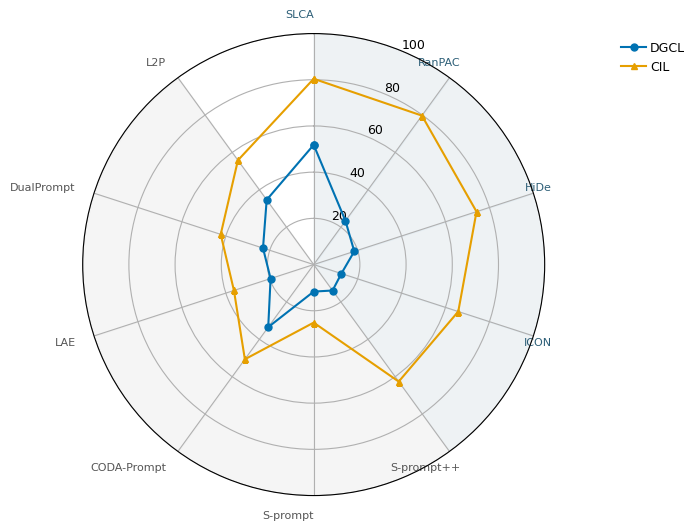

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 数据准备
methods = ['SLCA', 'RanPAC', 'HiDe', 'ICON', 'S-prompt++', 'S-prompt', 'CODA-Prompt', 'LAE', 'DualPrompt', 'L2P']
dgcl = [51.81, 23.40, 18.47, 12.61, 13.89, 11.70, 33.49, 19.62, 23.07, 34.62]
cil = [80.42, 79.70, 74.12, 65.81, 62.62, 25.13, 50.68, 36.30, 42.32, 55.80]

# 配色方案 (色盲友好)
palette = {
    'DGCL': '#0072B2',  # 深蓝
    'CIL': '#E69F00',   # 琥珀色
    'head_bg': '#D3E5EF',  # 浅蓝
    'feature_bg': '#F0F0F0',   # 浅灰
    'head_text': '#2C5E77',# 深蓝灰
    'std_text': '#555555'  # 中灰
}

# 图形参数优化
plt.rcParams.update({
    'font.size': 9,
    'axes.labelpad': 3,
    'lines.markersize': 6,
    'lines.linewidth': 1.5
})

# 角度计算
N = len(methods)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # 闭合圆形

fig = plt.figure(figsize=(6, 6))  # 紧凑尺寸
ax = fig.add_subplot(111, polar=True)

# 绘制扇形背景
for idx in range(N):
    color = palette['head_bg'] if methods[idx] in ['SLCA','RanPAC','HiDe','ICON'] else palette['feature_bg']
    ax.fill_between(np.linspace(angles[idx], angles[idx+1], 50), 
                    0, 100, 
                    color=color, 
                    alpha=0.4)

# 数据闭合处理
def wrap_data(data):
    return np.concatenate((data, [data[0]]))

# 绘制性能曲线
ax.plot(angles, wrap_data(dgcl), color=palette['DGCL'], 
        marker='o', markersize=5, label='DGCL')
ax.plot(angles, wrap_data(cil), color=palette['CIL'],
        marker='^', markersize=5, label='CIL')

# 坐标轴设置
ax.set_theta_offset(np.pi/2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(methods, rotation=30, ha='right')
plt.ylim(0, 100)

# 标签颜色设置
text_colors = [palette['head_text'] if m in ['SLCA','RanPAC','HiDe','ICON'] 
               else palette['std_text'] for m in methods]
for label, color in zip(ax.get_xticklabels(), text_colors):
    label.set_color(color)
    label.set_fontsize(8)

# 图例优化
legend = ax.legend(
    loc='upper left',
    bbox_to_anchor=(1.15, 1),
    frameon=False,
    handletextpad=0.3,
    borderaxespad=0.2
)

plt.savefig('DGCL_CIL_radar.pdf', 
           bbox_inches='tight', 
           dpi=300,
           transparent=True)
plt.show()

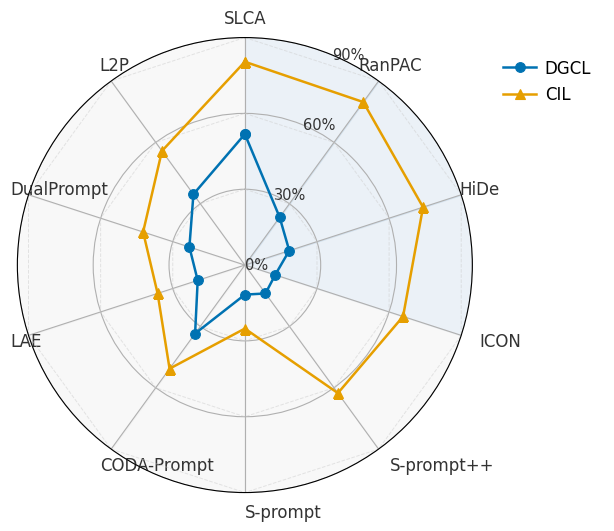

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

methods = ['SLCA', 'RanPAC', 'HiDe', 'ICON', 'S-prompt++', 'S-prompt', 'CODA-Prompt', 'LAE', 'DualPrompt', 'L2P']
dgcl = [51.81, 23.40, 18.47, 12.61, 13.89, 11.70, 33.49, 19.62, 23.07, 34.62]
cil = [80.42, 79.70, 74.12, 65.81, 62.62, 25.13, 50.68, 36.30, 42.32, 55.80]

head_methods = ['SLCA', 'RanPAC', 'HiDe', 'ICON']

palette = {
    'DGCL': '#0072B2',  # 牛津蓝
    'CIL': '#E69F00',    # 琥珀色
    'head_bg': '#BED3E6',# 浅蓝
    'feature_bg': '#EBEBEB', # 浅灰
    'grid': '#CCCCCC',   # 网格线颜色
    'text': '#333333'    # 主文本颜色
}

plt.rcParams.update({
    'font.size': 12,          # 基准字体放大
    'axes.titlesize': 12,     # 坐标轴标题
    'axes.labelsize': 12,     # 坐标轴标签
    'xtick.labelsize': 12,    # X轴刻度
    'ytick.labelsize': 12     # Y轴刻度
})

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, polar=True)
plt.subplots_adjust(left=0.1, right=0.75, top=0.95, bottom=0.1)  # 边距优化

N = len(methods)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles.append(2*np.pi)

# 绘制分度背景
for y in [0, 30, 60, 90]:
    ax.plot(angles, [y]*len(angles), color=palette['grid'], 
            linestyle='--', linewidth=0.7, alpha=0.5)

# 填充方法类别背景
for idx in range(N):
    if idx < N-1:
        if methods[idx] in head_methods and methods[idx+1] in head_methods:
            color = palette['head_bg']
        else:
            color = palette['feature_bg']
    else:
        color = palette['feature_bg']
    ax.fill_between(np.linspace(angles[idx], angles[idx+1], 50), 
                    0, 100, color=color, alpha=0.3)

# 数据闭合处理
def wrap_data(data):
    return np.concatenate((data, [data[0]]))

# 绘制性能曲线
ax.plot(angles, wrap_data(dgcl), color=palette['DGCL'], 
        marker='o', markersize=7, markeredgewidth=0.8, linewidth=1.8,
        label='DGCL')
ax.plot(angles, wrap_data(cil), color=palette['CIL'],
        marker='^', markersize=7, markeredgewidth=0.8, linewidth=1.8,
        label='CIL')

# 坐标轴设置
ax.set_theta_offset(np.pi/2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(methods, color=palette['text'])
plt.ylim(0, 90)

# 增强刻度标签
ax.set_yticks([0, 30, 60, 90])
ax.set_yticklabels(['0%', '30%', '60%', '90%'], 
                  color=palette['text'], 
                  fontsize=10.5,
                  verticalalignment='center')

# 旋转文本标签
for label, angle in zip(ax.get_xticklabels(), np.degrees(angles[:-1])):
    label.set_rotation(angle-90)  # 自动对齐径向
    label.set_horizontalalignment('center' if -90 < angle < 90 else 'left')

# 紧凑图例
legend = ax.legend(
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False,
    borderpad=0.8,
    handletextpad=0.5,
    fontsize=12
)

# 输出设置
plt.savefig('DGCL_CIL_radar.pdf', 
           bbox_inches='tight', 
           dpi=600,
           transparent=True)
plt.show()